In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import matplotlib as mpl

import torch
import torch.nn.functional as F

from transformers import BertTokenizer, BertForMaskedLM, logging

logging.set_verbosity_error()

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [3]:
model_name = 'bert-large-uncased'
model = BertForMaskedLM.from_pretrained(model_name)
model.to(device)
model.eval()

tokenizer = BertTokenizer.from_pretrained('bert-large-uncased')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.34G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/394 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [4]:
# Import text
text = 'The way you do anything is the [MASK] you do everything.'
token_ids = tokenizer.encode(text, return_tensors='pt', add_special_tokens=True)
token_ids = token_ids.to(device)

for tok in token_ids[0]:
    print(f'Token {tokenizer.decode(tok):10} ID:{tok:>5}')

# Index of the masked token
mask_idx = torch.where(token_ids == tokenizer.mask_token_id)[1].item()

Token [CLS]      ID:  101
Token the        ID: 1996
Token way        ID: 2126
Token you        ID: 2017
Token do         ID: 2079
Token anything   ID: 2505
Token is         ID: 2003
Token the        ID: 1996
Token [MASK]     ID:  103
Token you        ID: 2017
Token do         ID: 2079
Token everything ID: 2673
Token .          ID: 1012
Token [SEP]      ID:  102


In [5]:
# forward pass through the model to get the final logits
with torch.no_grad():
  output = model(token_ids, output_hidden_states=True)

The way you do anything is the [MASK] you do everything. 



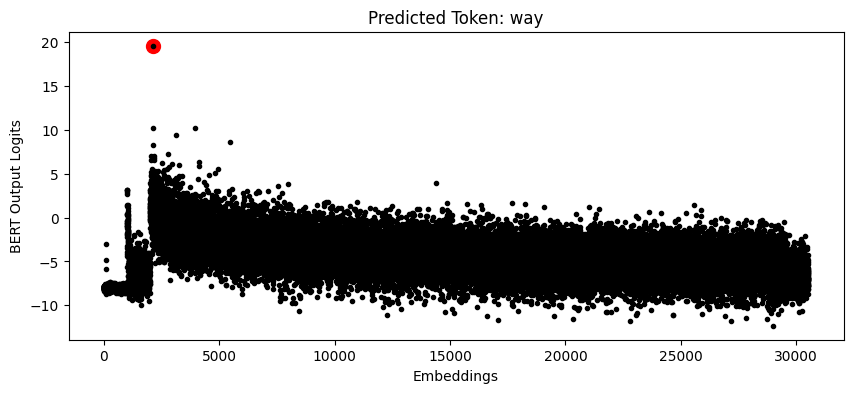

In [6]:
print(text,'\n')
mask_logits = output.logits[0, mask_idx, :]

# Get the top predicted tokens
top_token_idx = torch.argmax(mask_logits, axis=-1)

# Viusalize
plt.figure(figsize=(10, 4))
plt.plot(top_token_idx.cpu().numpy(), output.logits[0, mask_idx, top_token_idx].cpu().numpy(), 'ro', ms=10)
# logits for [MASK] token
plt.plot(mask_logits.cpu().numpy(), 'k.')
plt.gca().set(xlabel='Embeddings', ylabel='BERT Output Logits', title=f'Predicted Token: {tokenizer.decode(top_token_idx)}')


plt.show()

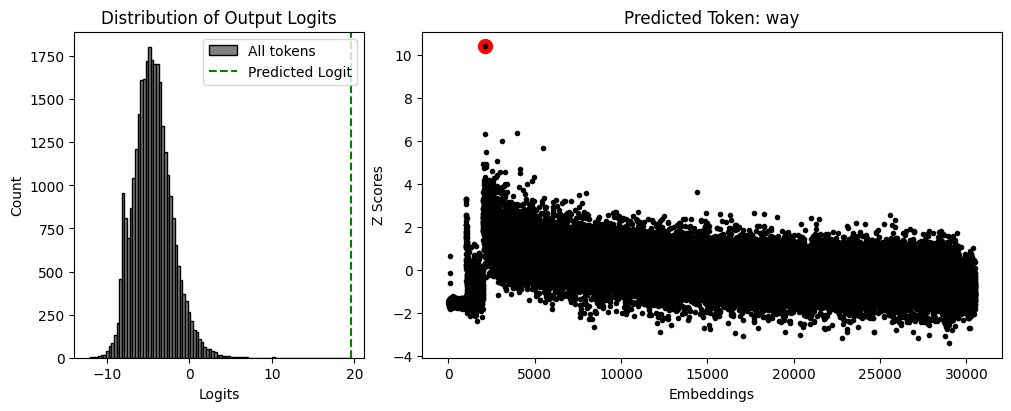

In [7]:
z_logits = (mask_logits - mask_logits.mean()) / mask_logits.std()

fig = plt.figure(figsize=(10, 4),constrained_layout="True")
gs = GridSpec(1,3, figure=fig)

ax0 = fig.add_subplot(gs[0])
ax1 = fig.add_subplot(gs[1:])

ax0.hist(mask_logits.cpu().numpy(), bins=100, edgecolor='k', facecolor='gray', density=False, label='All tokens')
ax0.axvline(mask_logits[top_token_idx].cpu().numpy(), ls='--', c='g', label='Predicted Logit')
ax0.set(xlabel='Logits', ylabel='Count', title='Distribution of Output Logits')
ax0.legend()

ax1.plot(top_token_idx.cpu().numpy(), z_logits[top_token_idx].cpu().numpy(), 'ro', ms=10)
# logits for [MASK] token
ax1.plot(z_logits.cpu().numpy(), 'k.')
ax1.set(xlabel='Embeddings', ylabel='Z Scores', title=f'Predicted Token: {tokenizer.decode(top_token_idx)}')


plt.show()

# Z-score and final logits output for all tokens

In [8]:
mask_id = tokenizer.mask_token_id
print(f'{"TARGET":10} | {"PREDICTED":10} | {"Z-SCORE":7}')
print('-' * 34)

for toki, tok in enumerate(token_ids[0]):

  target_token = tokenizer.decode(tok)

  # Replace each token by [MASK]
  token_ids_masked = token_ids.clone()
  token_ids_masked[0, toki] = mask_id

  # Forward pass the modified sentence through the model
  with torch.no_grad():
    output = model(token_ids_masked, output_hidden_states=True)

  mask_logits = output.logits[0, toki, :]
  z_logits = (mask_logits - mask_logits.mean()) / mask_logits.std()

  top_token_idx = torch.argmax(mask_logits, axis=-1)

  pred_token = tokenizer.decode(top_token_idx)

  print(f'{target_token:10} | {pred_token:10} | {z_logits[top_token_idx]:.2f}')



TARGET     | PREDICTED  | Z-SCORE
----------------------------------
[CLS]      | .          | 5.35
the        | the        | 12.04
way        | way        | 7.62
you        | you        | 10.34
do         | do         | 9.51
anything   | it         | 7.64
is         | .          | 10.51
the        | how        | 7.25
[MASK]     | way        | 10.39
you        | you        | 10.94
do         | do         | 9.20
everything | it         | 7.88
.          | .          | 15.12
[SEP]      | "          | 6.23


In [9]:
num_layers = model.config.num_hidden_layers + 1 # adding 1 for embedding layer

In [10]:
# Getting predicts from BERT (bypassing decoder layer)
masked_text = 'The way you do anything is the [MASK] you do everyting'
masked_tokens = tokenizer.encode(masked_text, return_tensors='pt').to(device)

In [11]:
with torch.no_grad():
  outputs = model(masked_tokens, output_hidden_states=True)

In [12]:
outputs.hidden_states[4].shape

torch.Size([1, 14, 1024])

In [13]:
# Get the unembedding matrix
unembed = model.cls.predictions.decoder.weight.detach()

acts = outputs.hidden_states[-3][0,8,:].detach()

mask_logits_wrong = (acts @ unembed.T).cpu()


In [14]:
# mask logits correct
mask_logits_correct = model.cls.predictions(acts).detach().cpu()

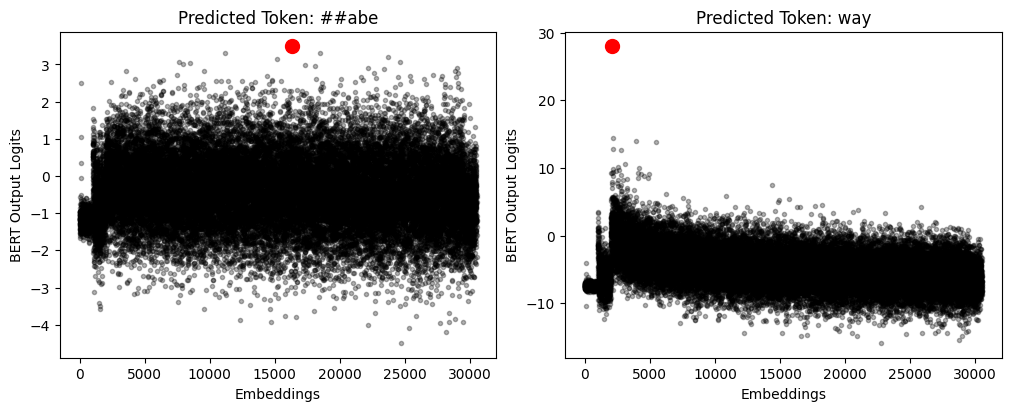

In [15]:

# Visualize
fig = plt.figure(figsize=(10, 4), layout='constrained')
axs = fig.subplots(1, 2)

top_token_idx = torch.argmax(mask_logits_wrong, axis=-1).cpu()

axs[0].plot(mask_logits_wrong,'k.', alpha=0.3)
axs[0].plot(top_token_idx, mask_logits_wrong[top_token_idx], 'ro', ms=10)
axs[0].set(xlabel='Embeddings', ylabel='BERT Output Logits', title=f'Predicted Token: {tokenizer.decode(top_token_idx)}')

top_token_idx = torch.argmax(mask_logits_correct, axis=-1).cpu()
axs[1].plot(mask_logits_correct,'k.', alpha=0.3)
axs[1].plot(top_token_idx, mask_logits_correct[top_token_idx], 'ro', ms=10)
axs[1].set(xlabel='Embeddings', ylabel='BERT Output Logits', title=f'Predicted Token: {tokenizer.decode(top_token_idx)}')


plt.show()



# Logit-lens for all layers

In [20]:
text = 'The way you do anything is the way you do everything.'
token_ids = tokenizer.encode(text, return_tensors='pt', add_special_tokens=True)
token_ids = token_ids.to(device)

In [22]:
# Initialize
mask_zscore = np.zeros((num_layers, len(token_ids[0])))
predicted_tokens = np.zeros((num_layers, len(token_ids[0])), dtype=int)

# Loop over all the tokens
for idx, _ in enumerate(token_ids[0]):
  # Create a masked version of the input tokens for the current position
  current_masked_token_ids = token_ids.clone()
  current_masked_token_ids[0, idx] = tokenizer.mask_token_id

  # Forward pass through the model to get hidden states for the current masked sentence
  with torch.no_grad():
    output = model(current_masked_token_ids, output_hidden_states=True)

  # Now, for this specific masked token position (idx), iterate through all layers
  for layeri in range(num_layers):

    # get internal logits for the masked token_id position
    acts = output.hidden_states[layeri][0, idx, :]

    # Apply logit lens
    mask_logits = model.cls.predictions(acts)

    # Get the predicted tokens
    predicted_token_id = torch.argmax(mask_logits, axis=-1)
    predicted_tokens[layeri, idx] = predicted_token_id.cpu().numpy()

    #Get the z-score
    mask_zscore[layeri, idx] = (mask_logits[predicted_token_id].item() - mask_logits.mean().item()) / mask_logits.std().item()

In [46]:
# Print the logit output for all layers
print('Original sentence:\n', text)
print()
for layeri in range(num_layers):
  print(f'Layer {layeri}')
  print(tokenizer.decode(predicted_tokens[layeri, 1:-1]))
  # print(tokenizer.decode(predicted_tokens[layeri]))
  print()

Original sentence:
 The way you do anything is the way you do everything.

Layer 0
games accreditation workers accreditationostalostalostal fellowship summer virginityostal fellowship

Layer 1
fellowship accreditation workers accreditationostal fellowship fellowship fellowship summer fellowship fellowshipostal

Layer 2
summer workers workers contract fellowship fellowship fellowship fellowship summer fellowship summerostal

Layer 3
accreditationcom workers contract fellowship fellowship fellowshipcom summercomostalostal

Layer 4
##comcom workerscomathlon fellowshipcomcomcomcomistocom

Layer 5
summercom summer contract summer fellowshipcomcom summercomistocom

Layer 6
toe foundation foundation at it at toe foundation through at..

Layer 7
##inas collegebridgebridgebridgealis indoor atop atop atopinasbular

Layer 8
atopalisalisalisbridgealisbridgealis atop atopbridgealis

Layer 9
atopalisbridgebridgebridgealisbridgebridgebridgebridgebridgealis

Layer 10
##alisalisalisalis fortealisalisal

In [23]:
print('Original text:\n', text, '\n')
print('Predictions at first transformer block:\n', tokenizer.decode(predicted_tokens[1,1:-1]), '\n')
print('Predictions at final transformer block:\n', tokenizer.decode(predicted_tokens[-1,1:-1]))

Original text:
 The way you do anything is the way you do everything. 

Predictions at first transformer block:
 fellowship accreditation workers accreditationostal fellowship fellowship fellowship summer fellowship fellowshipostal 

Predictions at final transformer block:
 the way you do it. the way you do it.


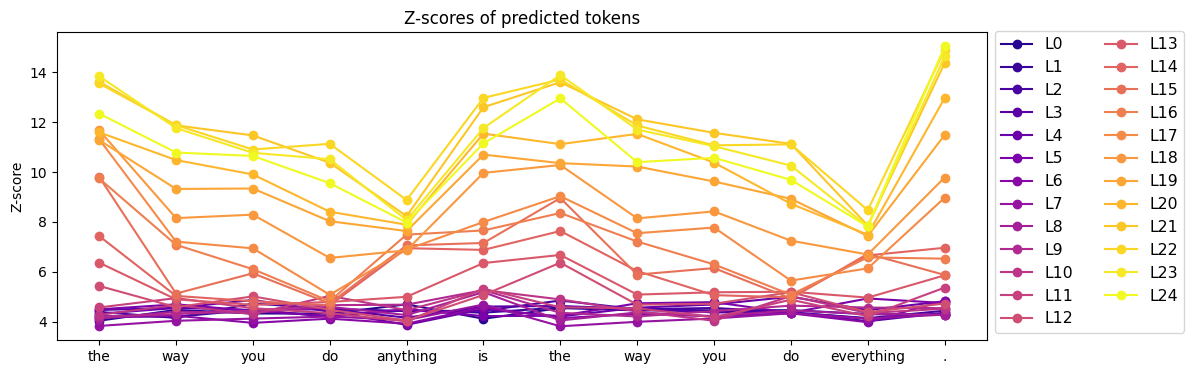

In [24]:
# lines visualization
plt.figure(figsize=(12,4))

for layeri in range(num_layers):
  plt.plot(range(len(token_ids[0])-2),mask_zscore[layeri,1:-1].T,'o-',color=mpl.cm.plasma((layeri+1)/num_layers),label=f'L{layeri}')

plt.gca().set(xticks=range(len(token_ids[0,1:-1])),xticklabels=[tokenizer.decode(t) for t in token_ids[0,1:-1]],
              ylabel='Z-score',title='Z-scores of predicted tokens')

plt.legend(fontsize=11.3,bbox_to_anchor=(1,1.03),ncol=2)
plt.show()

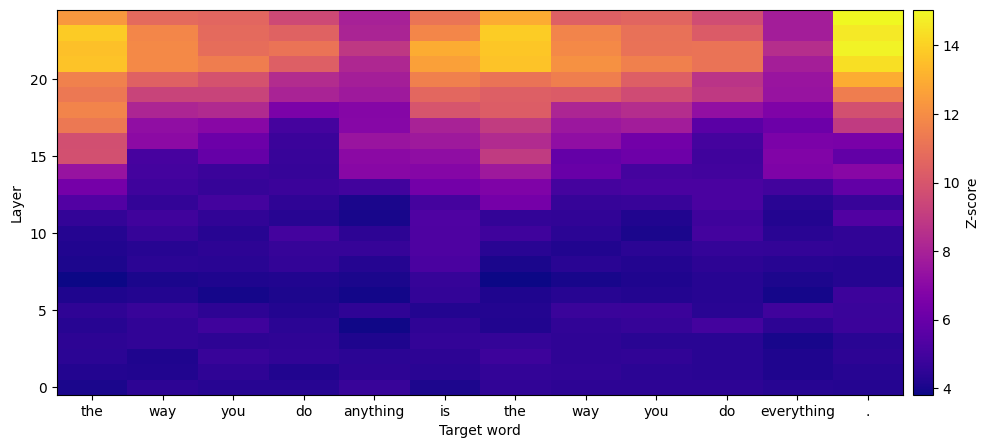

In [25]:
# and as an image
plt.figure(figsize=(13,5))
plt.imshow(mask_zscore[:,1:-1],aspect='auto',origin='lower',cmap='plasma')
plt.colorbar(pad=.01,label='Z-score')

plt.gca().set(xlabel='Target word',ylabel='Layer',
              xticks=range(len(token_ids[0,1:-1])),xticklabels=[tokenizer.decode(t) for t in token_ids[0,1:-1]])
plt.show()

# Logit Lens text heatmap

In [48]:
# scale z-scores
scaled_zscores = (mask_zscore-mask_zscore.min()) / (mask_zscore.max()-mask_zscore.min())
np.sort(scaled_zscores.flatten());

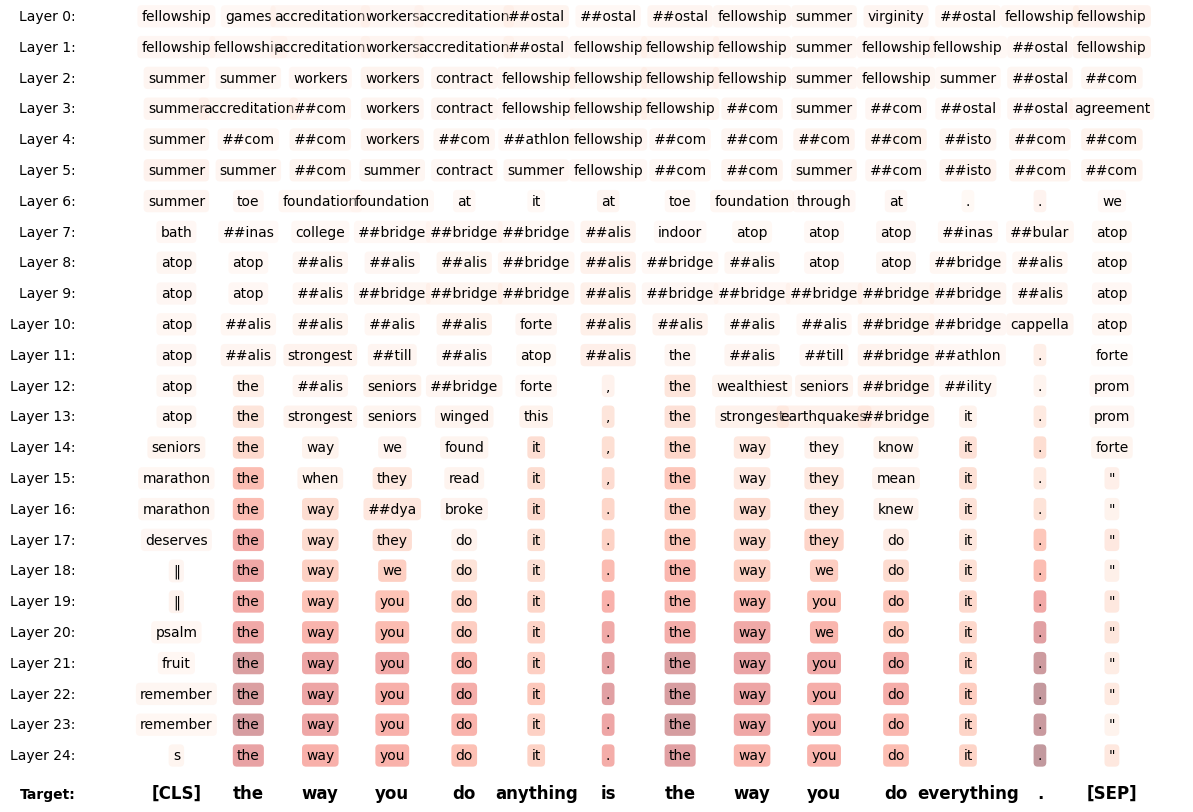

In [49]:
fig,ax = plt.subplots(1,figsize=(13,10))

# original text (separated into a list of decoded tokens)
target = [tokenizer.decode(t) for t in token_ids[0]]
numTokens = len(target)

# loop over layers
for layeri in range(num_layers):

  # y-axis coordinate for this layer
  yCoord = 1-layeri/num_layers

  # print the layer number in the left margin
  ax.text(-.1,yCoord,f'Layer {layeri}:',ha='right')

  # loop over the predicted tokens in this layer
  for xi,tok in enumerate(predicted_tokens[layeri]):
    ax.text(xi/numTokens,yCoord,tokenizer.decode(tok),ha='center',
            bbox=dict(boxstyle='round,pad=0.3', facecolor=mpl.cm.Reds(scaled_zscores[layeri,xi]), edgecolor='none',alpha=.4))

ax.axis('off')

# finally, draw the target tokens at the bottom
ax.text(-.1,yCoord-.05,f'Target:',ha='right',fontweight='bold')
for xi,tok in enumerate(target):
  ax.text(xi/numTokens,yCoord-.05,tok,ha='center',fontsize=12,fontweight='bold')

plt.show()